In [1]:
import multiprocessing as mp

import matplotlib.pyplot as plt
import torch
from alp_data import dataset_from_config
from hydra import compose, initialize
from hydra.utils import instantiate
from omegaconf import DictConfig, OmegaConf
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import pandas as pd

from bioacoustic_ssl.data import Compose, MixedStreamingDataset
from bioacoustic_ssl.models import MAE, ViTEncoder

In [2]:
import os
os.chdir("..")

In [3]:
def build_transforms(cfg_list, stage: str):   # stage: "train", "val", or "test"
    transforms = []
    for item in cfg_list:
        item = OmegaConf.to_container(item, resolve=True)
        allowed = item.pop("_stage_", ["train", "val", "test"])
        if stage in allowed:
            transforms.append(instantiate(item))
    return transforms

In [4]:
with initialize(config_path="../configs", version_base=None):
    cfg: DictConfig = compose(config_name="pretrain.yaml",
                  #overrides=["data/datasets=train/beans/cbi", "data/transforms=multiclass"]
                  overrides=["experiment=pretrain/pretrain_xc_pam_new"]
                  )

In [28]:
with initialize(config_path="../configs", version_base=None):
    cfg: DictConfig = compose(config_name="train.yaml",
                  #overrides=["data/datasets=train/beans/cbi", "data/transforms=multiclass"]
                  overrides=["data/datasets=train/birdset/sne"]
                  )

In [27]:
#pretrain
datasets = [instantiate(config) for config in list(cfg.data.datasets.values())[0:2]]
#len(datasets[0]) / 128 * 50

In [28]:
for data in datasets:
    print(data.__class__.__name__, len(data))

XenoCantoRaw 587628
NASAEarthAccess 46725


XenoCantoRaw 587628

Bioscape 46725

S2L 108440

SanctSound 167031

In [29]:
train_config = instantiate(cfg.data.datasets["train"])
test_config = config = instantiate(cfg.data.datasets["test"])

In [30]:
train_dataset, meta_train = dataset_from_config(train_config)
test_dataset, meta = dataset_from_config(test_config)
cfg.data.num_classes = meta["mulitlabel_from_feature"]["num_classes"]

In [8]:
# pretrain
train_dataset = MixedStreamingDataset(datasets=datasets)
# test_ds = MixedStreamingDataset(datasets=[test], transform=build_transforms(cfg.data.transforms, "test"))

In [9]:
dl = DataLoader(
    train_dataset,
    batch_size=20,
    #num_workers=4,
    #shuffle=True,
    #multiprocessing_context=mp.get_context("spawn"),
    #pin_memory=True,
    #persistent_workers=True,
    collate_fn=Compose(build_transforms(cfg.data.transforms, "train"))
)

In [10]:
dl_iter = iter(dl)

In [25]:
batch = next(dl_iter)

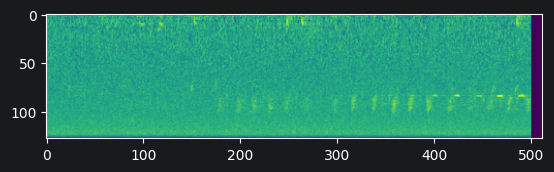

In [26]:
plt.imshow(batch["spectrogram"][10].squeeze())

In [ ]:
del cfg.module.model.pool
model = instantiate(cfg.module.model)

In [ ]:
model(batch["spectrogram"])